<a href="https://colab.research.google.com/github/AnisAkram/Spam-Email-Dtection-/blob/main/Email_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load custom Dataset

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Emails.csv")

df

,text,label
0,Congratulations! You have won a free iPhone. C...,spam
1,Meeting scheduled at 10 AM tomorrow. Please co...,ham
2,Earn money fast!!! Work from home and make $50...,spam
3,Your assignment deadline is next Monday. Submi...,ham
4,Limited time offer! Buy now and get 70% discou...,spam
...,...,...
95,Earn rewards points instantly by signing up to...,spam
96,GPT-5.2 is now live in the OpenAI API,ham
97,Don’t miss this chance to grab unbelievable de...,spam
98,Complete your gamma on desktop,ham


In [ ]:
df["label"].unique()

array(['spam', 'ham'], dtype=object)

In [ ]:
df.describe()


,text,label
count,100,100
unique,99,2
top,Earn $1000 per day working from home,spam
freq,2,50


# Data Cleaning


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df["text"] = df["text"].apply(clean_text)

# Convert labels
df["label"] = df["label"].map({"ham": 0, "spam": 1})
df

,text,label
0,congratulations you have won a free iphone cli...,1
1,meeting scheduled at am tomorrow please confi...,0
2,earn money fast work from home and make daily,1
3,your assignment deadline is next monday submit...,0
4,limited time offer buy now and get discount,1
...,...,...
95,earn rewards points instantly by signing up to...,1
96,gpt is now live in the openai api,0
97,dont miss this chance to grab unbelievable dea...,1
98,complete your gamma on desktop,0


# EDA

In [ ]:
print(df["label"].isnull().sum())

0


In [ ]:
df["label"].value_counts()

,count
label,
1,50
0,50


In [ ]:
df["length"] = df["text"].apply(len)
df

,text,label,length
0,congratulations you have won a free iphone cli...,1,66
1,meeting scheduled at am tomorrow please confi...,0,66
2,earn money fast work from home and make daily,1,46
3,your assignment deadline is next monday submit...,0,54
4,limited time offer buy now and get discount,1,44
...,...,...,...
95,earn rewards points instantly by signing up to...,1,58
96,gpt is now live in the openai api,0,35
97,dont miss this chance to grab unbelievable dea...,1,60
98,complete your gamma on desktop,0,30


# Data Visualization

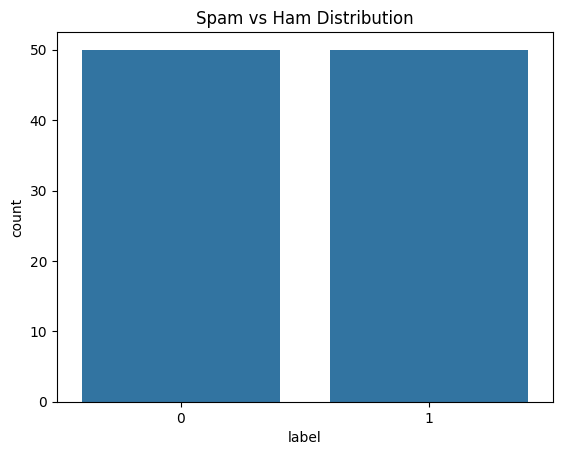

In [ ]:
sns.countplot(x=df["label"])
plt.title("Spam vs Ham Distribution")
plt.show()

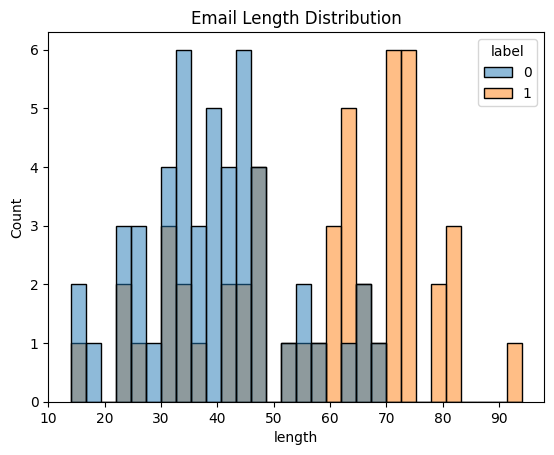

In [ ]:
sns.histplot(data=df, x="length", hue="label", bins=30)
plt.title("Email Length Distribution")
plt.show()

# Data Training

In [ ]:
from sklearn.model_selection import train_test_split
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# M-1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr_model = LogisticRegression()
lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.95


# M-2 Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.9


# Evolution metrix

In [ ]:
from sklearn.metrics import classification_report
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

print("=== Naive Bayes ===")
print(classification_report(y_test, nb_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.92      0.96        13

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20

=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.92      0.92      0.92        13

    accuracy                           0.90        20
   macro avg       0.89      0.89      0.89        20
weighted avg       0.90      0.90      0.90        20



# Confusion Matrix

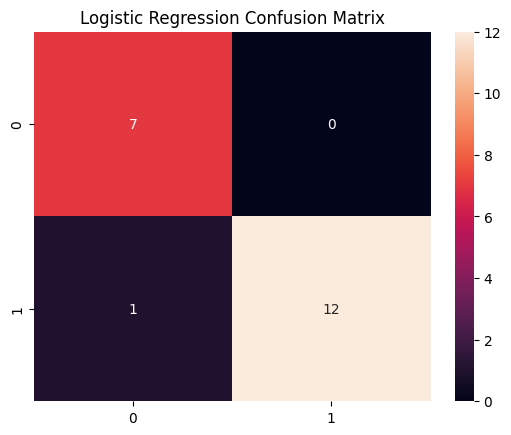

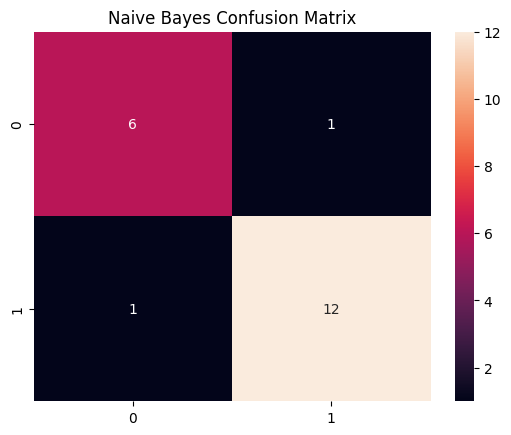

In [ ]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# Model Comparison

In [ ]:
lr_acc = accuracy_score(y_test, lr_pred)
nb_acc = accuracy_score(y_test, nb_pred)

print("Logistic Regression:", lr_acc)
print("Naive Bayes:", nb_acc)

Logistic Regression: 0.95
Naive Bayes: 0.9


# Final Prediction

In [ ]:
def predict_email(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])

    lr_result = lr_model.predict(vec)[0]
    nb_result = nb_model.predict(vec)[0]

    print("LR Prediction:", "Spam" if lr_result else "Ham")
    print("NB Prediction:", "Spam" if nb_result else "Ham")

predict_email("This is ML Lab project ")

LR Prediction: Ham
NB Prediction: Ham
